In [68]:
import os
import cv2 
import cv2 as cv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [69]:
def generate_density_map(shape, points, sigma=4):
    H, W = shape
    density = np.zeros((H, W), dtype=np.float32)

    for x, y in points:
        x, y = int(x), int(y)
        if x >= W or y >= H:
            continue

        density[y, x] += 1

    density = cv2.GaussianBlur(density, (15, 15), sigma)
    return density

In [ ]:
class TrancosDataset(Dataset):
    def __init__(self, root, downsample_factor=2):
        self.downsample_factor = downsample_factor
        self.img_dir = os.path.join(root, "images")
        self.dot_dir = os.path.join(root, "dots")
        self.mask_dir = os.path.join(root, "ground-truth")

        self.images = sorted([f for f in os.listdir(self.img_dir) if f.endswith(".jpg")])

        self.downsample_factor = downsample_factor  # ✅ FIX 1

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        dot_path = os.path.join(self.dot_dir, img_name.replace(".jpg", ".txt"))
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", "mask.mat"))

        # Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h0, w0, _ = img.shape  # original size

        img = cv2.resize(img, (img.shape[1]//self.downsample_factor, img.shape[0]//self.downsample_factor))

        h, w, _ = img.shape

        # Points
        points = []
        if os.path.exists(dot_path):
            with open(dot_path) as f:
                for line in f:
                    x, y = map(float, line.strip().split())

                    # ✅ FIX 3: scale points
                    x /= self.downsample_factor
                    y /= self.downsample_factor

                    points.append([x, y])

        points = np.array(points)

        # Mask
        mat = loadmat(mask_path)
        mask = mat["BW"]

        # ✅ FIX 4: resize mask to match image
        mask = cv2.resize(mask, (w, h))
        mask = (mask > 0).astype(np.float32)

        img = img * mask[:, :, None]

        # Density
        density = generate_density_map((h, w), points)

        density = cv2.resize(density, (w // 8, h // 8))

        if density.sum() > 0:
            density *= (len(points) / density.sum())

        density *= 100.0

        img = self.transform(img)
        density = torch.from_numpy(density).unsqueeze(0)

        return img, density

In [71]:
class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=2, dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)

In [72]:
DATA_ROOT = "TRANCOS - edited"

downsample_factor = 2  # Adjust as needed for memory constraints

train_ds = TrancosDataset(os.path.join(DATA_ROOT, "train_data"),downsample_factor=downsample_factor)
test_ds  = TrancosDataset(os.path.join(DATA_ROOT, "test_data"),downsample_factor=downsample_factor)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)

print("Train:", len(train_ds), "\nTest:", len(test_ds))

Train: 1031 
Test: 213


In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

EPOCHS = 10
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i, (img, density) in enumerate(train_loader):
        img = img.to(device)
        density = density.to(device)

        pred = model(img)
        loss = criterion(pred, density)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 75 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Training Image {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"✅ Epoch {epoch+1} DONE | Avg Loss: {avg_loss:.4f}\n")

Epoch 1/10 | Training Image 0/1031 | Loss: 0.0951
Epoch 1/10 | Training Image 75/1031 | Loss: 0.0005
Epoch 1/10 | Training Image 150/1031 | Loss: 0.0007
Epoch 1/10 | Training Image 225/1031 | Loss: 0.0004
Epoch 1/10 | Training Image 300/1031 | Loss: 0.0002
Epoch 1/10 | Training Image 375/1031 | Loss: 0.0001
Epoch 1/10 | Training Image 450/1031 | Loss: 0.0002
Epoch 1/10 | Training Image 525/1031 | Loss: 0.0001
Epoch 1/10 | Training Image 600/1031 | Loss: 0.0000
Epoch 1/10 | Training Image 675/1031 | Loss: 0.0001
Epoch 1/10 | Training Image 750/1031 | Loss: 0.0000
Epoch 1/10 | Training Image 825/1031 | Loss: 0.0002
Epoch 1/10 | Training Image 900/1031 | Loss: 0.0001
Epoch 1/10 | Training Image 975/1031 | Loss: 0.0001
✅ Epoch 1 DONE | Avg Loss: 0.0034

Epoch 2/10 | Training Image 0/1031 | Loss: 0.0000
Epoch 2/10 | Training Image 75/1031 | Loss: 0.0001
Epoch 2/10 | Training Image 150/1031 | Loss: 0.0000
Epoch 2/10 | Training Image 225/1031 | Loss: 0.0002
Epoch 2/10 | Training Image 300/103

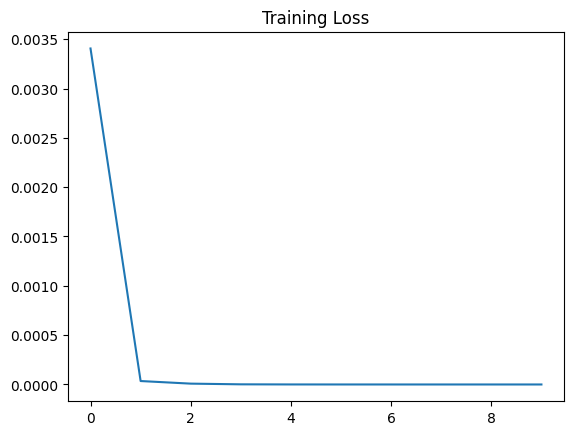

In [74]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

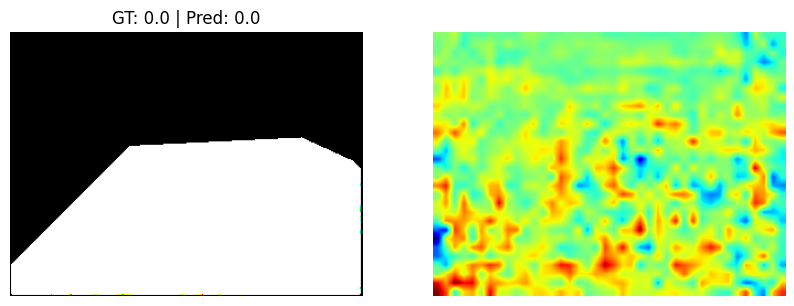

In [75]:
model.eval()

with torch.no_grad():
    for img, density in test_loader:

        img = img.to(device)
        pred = model(img)

        pred_count = pred.sum().item() / 100.0
        gt_count = density.sum().item() / 100.0

        img_np = img[0].permute(1,2,0).cpu().numpy()
        img_np = (img_np * [0.229,0.224,0.225] + [0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)

        density_map = pred[0,0].cpu().numpy()
        density_map = cv2.resize(density_map, (img_np.shape[1], img_np.shape[0]))

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(img_np)
        plt.title(f"GT: {gt_count:.1f} | Pred: {pred_count:.1f}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(density_map, cmap="jet")
        plt.axis("off")

        plt.show()
        break